# LS-LRSI: Historical-Point Validation and Output Consistency
## Aranayake / Devanagala, Kegalle District, Sri Lanka

**Student Name:** Aabidha Rifky
**ICBT SIS ID:** CL/MCSDS/CMU/10/04
**Cardiff Met ID:** st20357374
**Module:** DAS7003 Geospatial Analysis
**Assessment:** PRAC1

---

## Purpose

`04_index_construction.ipynb` built the LS-LRSI and saved its outputs (`ls_lrsi_risk_score.tif`, `ls_lrsi_risk_map.tif`, `ls_lrsi_full_results.csv`) to the `outputs/` folder. This notebook loads those saved files independently, rather than recomputing the index, and checks the result against the confirmed historical landslide coordinate for Devanagala. Running this validation in its own notebook, separate from construction, keeps the two concerns cleanly separated: Notebook 4 builds the index, this notebook checks it.

## 1. Load the Saved Index Outputs

In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.warp import transform as warp_transform

OUTPUT_DIR = "../outputs"
FIGURE_DIR = "../outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

# Load continuous risk score
with rasterio.open(
    f"{OUTPUT_DIR}/ls_lrsi_risk_score.tif"
) as src:

    risk_score = src.read(1)
    transform = src.transform
    crs = src.crs

# Load classified risk raster
with rasterio.open(
    f"{OUTPUT_DIR}/ls_lrsi_risk_map.tif"
) as src:

    risk_map_numeric = src.read(1)
    risk_map_transform = src.transform
    risk_map_crs = src.crs

# Load complete CSV
results = pd.read_csv(
    f"{OUTPUT_DIR}/ls_lrsi_full_results.csv"
)

print(
    f"Risk score grid: {risk_score.shape}, "
    f"coordinate system: {crs}"
)

print(
    f"Score range: "
    f"{risk_score.min():.3f} "
    f"to {risk_score.max():.3f}"
)

print(
    f"Results table: "
    f"{results.shape[0]} rows"
)

# ----------------------------------------------------
# Independent output consistency checks
# ----------------------------------------------------

shape_match = (
    risk_map_numeric.shape ==
    risk_score.shape
)

crs_match = (
    risk_map_crs ==
    crs
)

transform_match = (
    risk_map_transform ==
    transform
)

csv_row_match = (
    len(results) ==
    risk_score.size
)

finite_scores = np.isfinite(
    risk_score
).all()

# Reconstruct expected numeric classes directly
# from the continuous score thresholds
expected_numeric = np.select(
    [
        risk_score < 0.25,

        (risk_score >= 0.25) &
        (risk_score < 0.50),

        (risk_score >= 0.50) &
        (risk_score < 0.75),

        risk_score >= 0.75
    ],
    [1, 2, 3, 4],
    default=0
).astype("uint8")

classification_match = np.array_equal(
    expected_numeric,
    risk_map_numeric
)

csv_score_match = np.allclose(
    results["risk_score"].to_numpy(),
    risk_score.flatten(),
    atol=1e-6,
    rtol=0
)

number_to_class = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

expected_csv_classes = np.vectorize(
    number_to_class.get
)(
    risk_map_numeric
).flatten()

csv_class_match = np.array_equal(
    results["risk_class"].to_numpy(),
    expected_csv_classes
)

print("\nOutput consistency checks:")
print(f"  Raster shapes match: {shape_match}")
print(f"  Raster CRS match: {crs_match}")
print(f"  Raster transforms match: {transform_match}")
print(f"  CSV row count matches grid: {csv_row_match}")
print(f"  All score values finite: {finite_scores}")
print(
    "  Classified raster matches score thresholds: "
    f"{classification_match}"
)
print(
    "  CSV scores match score raster: "
    f"{csv_score_match}"
)
print(
    "  CSV classes match classified raster: "
    f"{csv_class_match}"
)

all_checks_pass = all([
    shape_match,
    crs_match,
    transform_match,
    csv_row_match,
    finite_scores,
    classification_match,
    csv_score_match,
    csv_class_match
])

if not all_checks_pass:
    raise ValueError(
        "One or more saved LS-LRSI outputs are inconsistent."
    )

print("\nAll saved-output consistency checks passed.")

Risk score grid: (221, 221), coordinate system: EPSG:32644
Score range: 0.105 to 0.574
Results table: 48841 rows

Output consistency checks:
  Raster shapes match: True
  Raster CRS match: True
  Raster transforms match: True
  CSV row count matches grid: True
  All score values finite: True
  Classified raster matches score thresholds: True
  CSV scores match score raster: True
  CSV classes match classified raster: True

All saved-output consistency checks passed.


The saved outputs from `04_index_construction.ipynb` are internally consistent. The continuous and classified rasters have matching dimensions, coordinate reference system and spatial transform; the classified raster exactly matches the stated score thresholds; and the CSV contains the same scores and classes as the raster outputs. These checks confirm that the validation below is being performed against the correctly saved final LS-LRSI outputs rather than against a separately recomputed version.

## 2. Locate the Known Landslide Site

The study grid is centred on 7.218418 N, 80.339762 E, NBRO's published coordinate for the 17 May 2016 Devanagala landslide. This finds which grid cell that coordinate falls into.

In [2]:
def classify_risk_value(score):
    if score < 0.25: return "Low"
    elif score < 0.50: return "Medium"
    elif score < 0.75: return "High"
    else: return "Very High"

landslide_lon, landslide_lat = 80.339762, 7.218418

x, y = warp_transform("EPSG:4326", crs, [landslide_lon], [landslide_lat])
row, col = rasterio.transform.rowcol(transform, x[0], y[0])

score_at_site = risk_score[row, col]
class_at_site = classify_risk_value(score_at_site)

print(f"Landslide site falls at grid cell (row {row}, col {col})")
print(f"Risk score at the site: {score_at_site:.3f}")
print(f"Risk class at the site: {class_at_site}")

Landslide site falls at grid cell (row 109, col 110)
Risk score at the site: 0.355
Risk class at the site: Medium


Because the study grid is centred on this coordinate, the historical landslide site falls close to the centre of the 221 × 221 grid, at row 109 and column 110. The saved LS-LRSI assigns the location a score of 0.355, corresponding to the Medium class. This value is obtained directly from the final saved risk-score raster rather than from a recomputation of the index.

## 3. Check the Surrounding Neighbourhood

A single grid cell is sensitive to small GPS positioning error in the reported coordinate. This checks a 5x5 cell window (roughly 150 m across) around the site.

In [3]:
window = 2

row_min = max(
    0,
    row - window
)

row_max = min(
    risk_score.shape[0],
    row + window + 1
)

col_min = max(
    0,
    col - window
)

col_max = min(
    risk_score.shape[1],
    col + window + 1
)

neighbourhood = risk_score[
    row_min:row_max,
    col_min:col_max
]

neighbourhood_classes = np.vectorize(
    classify_risk_value
)(neighbourhood)

unique_classes, class_counts = np.unique(
    neighbourhood_classes,
    return_counts=True
)

print(
    f"Neighbourhood "
    f"({neighbourhood.shape[0]}x"
    f"{neighbourhood.shape[1]} cells):"
)

print(
    f"  Mean score: "
    f"{neighbourhood.mean():.3f}"
)

print(
    f"  Min score: "
    f"{neighbourhood.min():.3f} "
    f"({classify_risk_value(neighbourhood.min())})"
)

print(
    f"  Max score: "
    f"{neighbourhood.max():.3f} "
    f"({classify_risk_value(neighbourhood.max())})"
)

print("\nNeighbourhood class counts:")

for class_name, count in zip(
    unique_classes,
    class_counts
):
    print(
        f"  {class_name}: "
        f"{count} cells"
    )

print(
    f"\nStudy area overall mean score: "
    f"{risk_score.mean():.3f}"
)

Neighbourhood (5x5 cells):
  Mean score: 0.288
  Min score: 0.228 (Low)
  Max score: 0.388 (Medium)

Neighbourhood class counts:
  Low: 4 cells
  Medium: 21 cells

Study area overall mean score: 0.300


**Interpretation:** the historical landslide site is classified Medium with a score of 0.355, above the study-area mean of 0.300. The surrounding 5 × 5-cell neighbourhood has a slightly lower mean score of 0.288, with values ranging from 0.228 (Low) to 0.388 (Medium). Of the 25 cells in the neighbourhood, 21 are Medium and 4 are Low.

The historical site therefore scores above both the overall study-area mean and the immediate-neighbourhood mean. However, the surrounding window is not uniformly elevated and contains no High-risk cells. With only one historical landslide point available, this result should be treated as a limited face-validity check rather than statistical evidence of predictive accuracy.

## 4. Visualise the Site in Context

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm
risk_cmap = ListedColormap(["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"])
risk_norm = BoundaryNorm([0, 0.25, 0.50, 0.75, 1.0], risk_cmap.N)

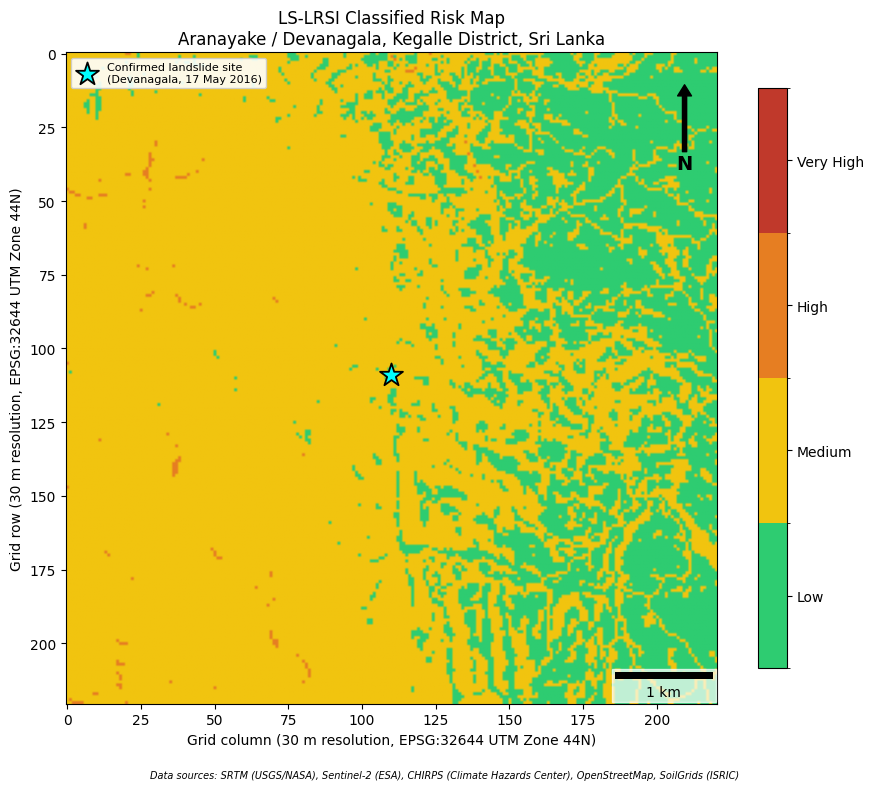

In [5]:
from matplotlib_scalebar.scalebar import ScaleBar

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(risk_score, cmap=risk_cmap, norm=risk_norm)

ax.scatter(col, row, marker="*", s=300, color="cyan", edgecolor="black", linewidth=1.3,
           label="Confirmed landslide site\n(Devanagala, 17 May 2016)", zorder=5)

ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.82), xycoords="axes fraction",
            fontsize=14, fontweight="bold", ha="center",
            arrowprops=dict(facecolor="black", width=3, headwidth=10, headlength=8))

scalebar = ScaleBar(30, units="m", location="lower right", box_alpha=0.7, color="black")
ax.add_artist(scalebar)

ax.set_title("LS-LRSI Classified Risk Map\nAranayake / Devanagala, Kegalle District, Sri Lanka", fontsize=12)
ax.set_xlabel("Grid column (30 m resolution, EPSG:32644 UTM Zone 44N)")
ax.set_ylabel("Grid row (30 m resolution, EPSG:32644 UTM Zone 44N)")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

cbar = plt.colorbar(im, ax=ax, ticks=[0.125, 0.375, 0.625, 0.875], shrink=0.8)
cbar.ax.set_yticklabels(["Low", "Medium", "High", "Very High"])

fig.text(0.5, 0.01, "Data sources: SRTM (USGS/NASA), Sentinel-2 (ESA), CHIRPS (Climate Hazards Center), OpenStreetMap, SoilGrids (ISRIC)",
          ha="center", fontsize=7, style="italic")

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("../outputs/figures/fig3_validation_map.png", dpi=160, bbox_inches="tight")
plt.show()

This figure shows the confirmed landslide location marked directly on the classified risk map, providing a clear visual complement to the numerical validation above. It confirms visually that the marker sits within a Medium-risk (yellow) cell, consistent with the score reported in Section 2.